# U-MobileViT-Net **PRO** — Model Dissection & Layer-wise Activation Heatmaps

**Dataset**: COCO Tea Leaf | 8-class synthetic agricultural disease segmentation  
**Model**: U-MobileViT-Net **Pro** (d_model=128, ~2.8M parameters)  
**Checkpoint**: `checkpoints/coco_leaf/pro/best_model.pth`  
**Input resolution**: 320 × 320 pixels  

This notebook dissects the trained **pro** model by registering forward hooks on every  
meaningful sub-layer (stem, encoder stages, decoder stages, seg head) and visualising  
their activation maps as heatmaps. The goal is to understand **what each layer sees**  
and how features evolve through the network.

### Architecture recap (Pro variant, d_model=128)
```
Input (3, 320, 320)
  │
  ├─ Stem[0]: Conv3×3 s2  →  32ch, 160×160
  ├─ Stem[1]: Conv3×3 s2  →  64ch,  80×80
  ├─ Stem[2]: Conv3×3 s2  → 128ch,  40×40
  │
  ├─ Enc Stage 1: DS Conv3×3 s2 + 1×EncoderLayer  → 128ch, 20×20
  ├─ Enc Stage 2: DS Conv3×3 s2 + 2×EncoderLayer  → 128ch, 10×10
  ├─ Enc Stage 3: DS Conv3×3 s2 + 2×EncoderLayer  → 128ch,  5×5  (patch=1×1)
  │
  ├─ Dec Stage 1: Upsample ×2 + 2×DecoderLayer  → 128ch, 10×10
  ├─ Dec Stage 2: Upsample ×2 + 1×DecoderLayer  → 128ch, 20×20
  ├─ Dec Out:     Upsample ×2 + ConcatLayer      → 128ch, 40×40
  │
  ├─ SegHead x2:  Upsample → 64ch,  80×80  + concat stem[1]
  ├─ SegHead x4:  Upsample → 32ch, 160×160  + concat stem[0]
  ├─ SegHead x8:  Upsample → 16ch, 320×320
  ├─ Refinement:  Dilated Conv + Spatial Attention
  └─ Classifier:  Depthwise 3×3 → Pointwise 1×1 → 8ch, 320×320
```

Each EncoderLayer / DecoderLayer internally contains:
- **local_block**: Depthwise 3×3 → Pointwise 1×1 → ReLU → GroupNorm
- **global_block**: N Transformer blocks (self-attention in encoder, cross-attention in decoder)
- **expansion_block**: Inverted bottleneck (expand → depthwise → project) + ReLU6 + GroupNorm
- **out_norm**: GroupNorm on the residual connection

In [1]:
# --- Section 1: Environment and Imports ----------------------------------------

import sys, os
from pathlib import Path
import numpy as np
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from collections import OrderedDict
from typing import Dict, List, Tuple, Optional

def setup_environment():
    current = Path.cwd()
    project_root = current
    for parent in [current] + list(current.parents):
        if (parent / ".git").exists() or (parent / "README.md").exists():
            project_root = parent
            break

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    os.environ.setdefault("PYTHONPATH", str(project_root))
    os.chdir(str(project_root))
    print(f"Project root: {project_root}")
    return project_root

project_root = setup_environment()

from src.model import UNetLite
from models.u_mobilevit_net_base import UNetMobileViT
from tools.data import create_dataloaders, label_to_color, denormalize
from tools.visualization import configure_paper_style, TOL_PALETTE

def get_variant(variant):
    specs = {
        "unet_lite_no_attn": {"d_model": 128, "num_transformer_blocks": 0, "expansion_factor": 2, "params_estimate": "1.6M"},
    }
    return specs.get(variant, specs["unet_lite_no_attn"])

configure_paper_style()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Project root: /home/lenovo/a3_dl_fn/UNet_Training_From_Scratch


Device: cuda


In [2]:
# --- Section 2: Configuration ---------------------------------------------------

CFG = {
    "dataset": "coco_person",
    "variant": "unet_lite_no_attn",
    "image_size": (320, 320),
    "batch_size": 1,
    "checkpoint": "models/unet_base_copy/best_unet_base.pth",
}

variant_spec = get_variant(CFG["variant"])
print(f"Model variant: UNet-lite")
print(f"  d_model:             {variant_spec['d_model']}")
print(f"  Transformer blocks:  {variant_spec['num_transformer_blocks']}")
print(f"  Expansion factor:    {variant_spec['expansion_factor']}")
print(f"  Estimated params:    {variant_spec['params_estimate']}")
print(f"  Checkpoint:          {CFG['checkpoint']}")


Model variant: UNet-lite
  d_model:             128
  Transformer blocks:  0
  Expansion factor:    2
  Estimated params:    1.6M
  Checkpoint:          models/unet_base_copy/best_unet_base.pth


loading annotations into memory...


Done (t=27.91s)
creating index...


index created!
loading annotations into memory...


Done (t=1.50s)
creating index...
index created!


PersonStampPool: 1131 stamps sẵn sàng
Dataset: COCO Person
  Classes:     1 (binary)
  Class names: person
  Input size:  (320, 320)
  Val samples: 2,693

Loaded target image 000000004134.jpg
Sample image: (1, 3, 320, 320)
Sample mask:  (1, 1, 320, 320)
Mask unique:  [0.0, 1.0]


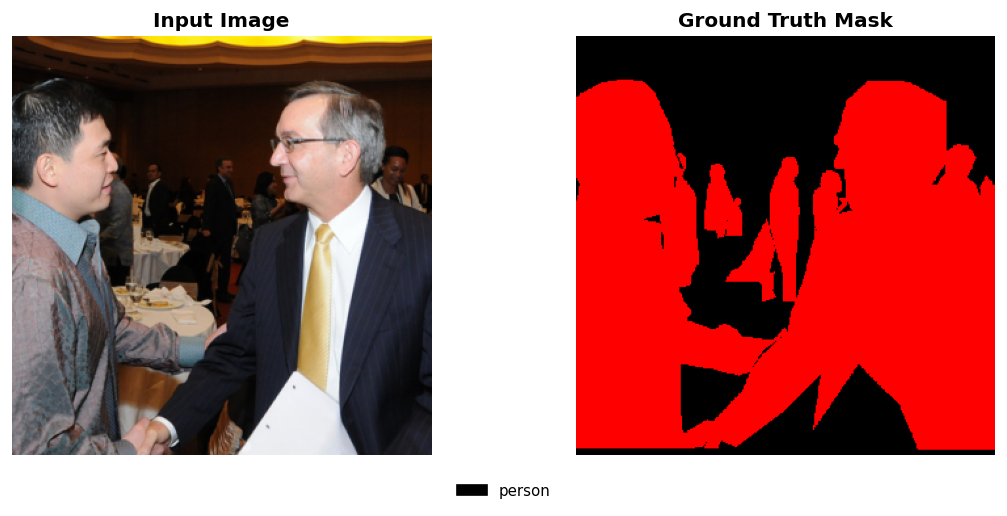

In [3]:
# --- Section 3: Data Loading (single sample) ------------------------------------

def load_single_sample(config, selected_idx=0):
    """Load the custom 4 target validation images + masks for dissection."""
    _, val_loader, info = create_dataloaders(
        config["dataset"],
        image_size=config["image_size"],
        batch_size=1,
        num_workers=4,
        aug_intensity="light",
    )
    
    # Map the selected index to target COCO validation indices
    # Image filenames: 000000008532.jpg, 000000002685.jpg, 000000004134.jpg, 000000005529.jpg
    # Corresponding indices in val_loader.dataset: 110, 884, 1316, 1798
    target_indices = [110, 884, 1316, 1798]
    val_idx = target_indices[selected_idx]
    img_names = ["000000008532", "000000002685", "000000004134", "000000005529"]
    
    use_local_fallback = False
    if val_idx >= len(val_loader.dataset):
        print(f"⚠️  Dataset size is {len(val_loader.dataset)}, but target index is {val_idx}. Using local image fallback.")
        use_local_fallback = True
    else:
        try:
            img, mask = val_loader.dataset[val_idx]
        except Exception as e:
            print(f"Failed to load validation sample {val_idx}: {e}. Using local image fallback.")
            use_local_fallback = True
            
    if use_local_fallback:
        from PIL import Image as PILImage
        import torchvision.transforms.functional as TF
        from src.dataset import IMAGENET_MEAN, IMAGENET_STD
        from torchvision.transforms import InterpolationMode
        
        local_img_path = f"/home/lenovo/a3_dl_fn/UNet_Training_From_Scratch/{img_names[selected_idx]}.jpg"
        image = PILImage.open(local_img_path).convert("RGB")
        short_edge = min(config["image_size"])
        img = TF.resize(image, short_edge, interpolation=InterpolationMode.BILINEAR)
        img = TF.center_crop(img, config["image_size"])
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=IMAGENET_MEAN, std=IMAGENET_STD)
        mask = torch.zeros(1, *config["image_size"])
        
    # Add batch dimension to match loader format
    images = img.unsqueeze(0)
    masks = torch.tensor(mask).unsqueeze(0) if isinstance(mask, (np.ndarray, list)) else mask.unsqueeze(0)
    
    print(f"Dataset: {info.name}")
    print(f"  Classes:     {info.num_classes} ({info.type})")
    print(f"  Class names: {', '.join(info.class_names)}")
    print(f"  Input size:  {info.image_size}")
    print(f"  Val samples: {info.val_size:,}")
    print(f"\nLoaded target image {img_names[selected_idx]}.jpg")
    print(f"Sample image: {tuple(images.shape)}")
    print(f"Sample mask:  {tuple(masks.shape)}")
    print(f"Mask unique:  {masks.unique().tolist()}")
    
    # Save target indices and val_loader reference globally
    global custom_target_indices, custom_val_loader
    custom_target_indices = target_indices
    custom_val_loader = val_loader
    
    return images, masks, info

# Set index from 0 to 3 to select which image to analyze (0: 1296, 1: 2685, 2: 4134, 3: 5529)
selected_img_idx = 2
sample_img, sample_mask, info = load_single_sample(CFG, selected_idx=selected_img_idx)

# Visualise the input
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Image (denormalised from ImageNet stats — denormalize returns (H, W, C) numpy)
img_np = denormalize(sample_img[0])
axes[0].imshow(img_np)
axes[0].set_title("Input Image", fontweight="bold")
axes[0].axis("off")

# Mask
mask_np = sample_mask[0].numpy()
colored = label_to_color(mask_np, info.palette)
axes[1].imshow(colored)
axes[1].set_title("Ground Truth Mask", fontweight="bold")
axes[1].axis("off")

# Legend
palette_01 = info.palette / 255.0
patches = [mpatches.Patch(color=palette_01[i], label=name)
           for i, name in enumerate(info.class_names)]
fig.legend(handles=patches, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.show()


In [4]:
# --- Section 4: Model Loading ---------------------------------------------------

def build_and_load_model(info, config):
    variant = config["variant"]
    if variant == "unet_lite_no_attn":
        model = UNetLite(None, use_attention=False)
        
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model: UNet-lite")
    print(f"  Parameters: {n_params:,} ({n_params / 1e6:.2f} M)")

    # Load checkpoint
    ckpt_path = config["checkpoint"]
    if os.path.exists(ckpt_path):
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)
        state_dict = ckpt.get("model_state_dict", ckpt)
        model.load_state_dict(state_dict, strict=False)
        print(f"  Checkpoint:  loaded (epoch {ckpt.get('epoch', '?')})")
    else:
        print(f"  WARNING: checkpoint not found at {ckpt_path}, using random weights!")

    model = model.to(device)
    model.eval()

    # Smoke test
    with torch.no_grad():
        dummy = torch.randn(1, 3, *config["image_size"]).to(device)
        out = model(dummy)
        print(f"  Smoke test:  {tuple(dummy.shape)} -> {tuple(out.shape)}  PASSED")

    # Weight check
    nan_params = [n for n, p in model.named_parameters() if not torch.isfinite(p).all()]
    if nan_params:
        raise RuntimeError(f"{len(nan_params)} parameters contain NaN/Inf!")
    print("  Weight check: all parameters finite")

    return model, n_params

model, n_params = build_and_load_model(info, CFG)

# Print full model structure
print("\n" + "=" * 72)
print("MODEL STRUCTURE")
print("=" * 72)
print(model)


Model: UNet-lite
  Parameters: 1,647,816 (1.65 M)
  Checkpoint:  loaded (epoch 30)


  Smoke test:  (1, 3, 320, 320) -> (1, 1, 320, 320)  PASSED
  Weight check: all parameters finite

MODEL STRUCTURE
UNetLite(
  (quant): QuantStub()
  (dequant): DeQuantStub()
  (f_cat): FloatFunctional(
    (activation_post_process): Identity()
  )
  (encoder_blocks): ModuleList(
    (0): MV2DoubleBlock(
      (block1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2d(3, 6, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): LeakyReLU(inplace=False, negative_slope=0.1)
          (3): Conv2d(6, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=6, bias=False)
          (4): BatchNorm2d(6, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): LeakyReLU(inplace=False, negative_slope=0.1)
          (6): Conv2d(6, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (7): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track

In [5]:
# --- Section 5: Hook Registration & Feature Extraction --------------------------

class FeatureExtractor:
    def __init__(self, model: nn.Module):
        self.model = model
        self.activations = OrderedDict()
        self._handles = []

    def _hook_fn(self, name: str):
        def hook(module, input, output):
            if isinstance(output, torch.Tensor):
                self.activations[name] = output.detach().cpu()
            elif isinstance(output, (tuple, list)):
                for i, o in enumerate(output):
                    if isinstance(o, torch.Tensor):
                        self.activations[f"{name}[{i}]"] = o.detach().cpu()
        return hook

    def register_hooks(self):
        for name, module in self.model.named_modules():
            # Register hooks for main layers dynamically
            if name in [
                "encoder_blocks.0", "encoder_blocks.1", "encoder_blocks.2", "encoder_blocks.3", "encoder_blocks.4",
                "bottleneck", "bottleneck_in", "bottleneck_attn", "bottleneck_out",
                "decoder_blocks.0", "decoder_blocks.1", "decoder_blocks.2", "decoder_blocks.3", "decoder_blocks.4",
                "final_conv"
            ]:
                self._handles.append(module.register_forward_hook(self._hook_fn(name)))

    def extract(self, image: torch.Tensor) -> OrderedDict:
        self.activations.clear()
        with torch.no_grad():
            self.model(image)
        return self.activations

    def remove_hooks(self):
        for handle in self._handles:
            handle.remove()
        self._handles.clear()

extractor = FeatureExtractor(model)
extractor.register_hooks()

img_gpu = sample_img.to(device)
activations = extractor.extract(img_gpu)

print(f"Captured {len(activations)} activation maps:")
for name, tensor in activations.items():
    print(f"  {name:<50s}  shape={tuple(tensor.shape)}")


Captured 12 activation maps:
  encoder_blocks.0                                    shape=(1, 8, 320, 320)
  encoder_blocks.1                                    shape=(1, 16, 160, 160)
  encoder_blocks.2                                    shape=(1, 32, 80, 80)
  encoder_blocks.3                                    shape=(1, 64, 40, 40)
  encoder_blocks.4                                    shape=(1, 128, 20, 20)
  bottleneck                                          shape=(1, 256, 10, 10)
  decoder_blocks.0                                    shape=(1, 128, 20, 20)
  decoder_blocks.1                                    shape=(1, 64, 40, 40)
  decoder_blocks.2                                    shape=(1, 32, 80, 80)
  decoder_blocks.3                                    shape=(1, 16, 160, 160)
  decoder_blocks.4                                    shape=(1, 8, 320, 320)
  final_conv                                          shape=(1, 1, 320, 320)


In [6]:
# --- Section 6: Heatmap Visualisation Utilities ---------------------------------

def activation_heatmap(
    tensor: torch.Tensor,           # (1, C, H, W)
    ax: plt.Axes,
    title: str = "",
    cmap: str = "inferno",
    show_colorbar: bool = True,
    percentile_clip: float = 98.0,  # clip top percentile for better contrast
):
    """Plot channel-averaged activation as a 2D heatmap.

    Averages across the channel dimension to produce a single spatial map
    showing where the layer is most active.
    """
    assert tensor.dim() == 4, f"Expected 4D tensor (1,C,H,W), got {tensor.dim()}D"
    feat = tensor[0]                    # (C, H, W)
    amap = feat.abs().mean(dim=0)        # (H, W) — mean absolute activation

    # Clip outliers for better contrast
    vmax = np.percentile(amap.numpy(), percentile_clip)
    vmin = amap.min().item()

    im = ax.imshow(amap.numpy(), cmap=cmap, norm=Normalize(vmin=vmin, vmax=vmax))
    ax.set_title(title, fontsize=8, fontweight="bold")
    ax.axis("off")
    if show_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)


def channel_heatmap_grid(
    tensor: torch.Tensor,           # (1, C, H, W)
    n_cols: int = 8,
    title: str = "",
    cmap: str = "inferno",
    figsize_scale: float = 1.5,
):
    """Plot first K channels as individual heatmaps in a grid.

    Useful for seeing what individual filters have learned.
    """
    C = tensor.shape[1]
    n_show = min(C, 32)  # show at most 32 channels
    n_rows = int(np.ceil(n_show / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * figsize_scale, n_rows * figsize_scale))
    axes = axes.flatten() if n_rows > 1 else ([axes] if n_cols == 1 else axes)

    for c in range(n_show):
        amap = tensor[0, c].numpy()
        vmax = np.percentile(amap, 98)
        im = axes[c].imshow(amap, cmap=cmap, norm=Normalize(vmin=amap.min(), vmax=vmax))
        axes[c].set_title(f"ch {c}", fontsize=7)
        axes[c].axis("off")

    for c in range(n_show, len(axes)):
        axes[c].axis("off")

    fig.suptitle(title, fontweight="bold", fontsize=11, y=1.01)
    plt.tight_layout()
    return fig


def plot_activation_summary(
    activations: OrderedDict,
    keys: List[str],
    title: str,
    n_cols: int = 4,
    figsize_per_row: float = 3.5,
):
    """Plot channel-mean heatmaps for a list of activation keys in a grid."""
    valid_keys = [k for k in keys if k in activations]
    if not valid_keys:
        print(f"  (none found for {title})")
        return

    n_rows = int(np.ceil(len(valid_keys) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * figsize_per_row, n_rows * figsize_per_row))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, key in enumerate(valid_keys):
        activation_heatmap(activations[key], axes[i], title=key, show_colorbar=(i == 0))
    for j in range(len(valid_keys), len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontweight="bold", fontsize=13, y=1.02)
    plt.tight_layout()
    return fig


def plot_side_by_side_heatmaps(
    activations: OrderedDict,
    key_pairs: List[Tuple[str, str, str]],  # (key, label, description)
    suptitle: str = "",
    n_cols: int = 2,
    figsize_per_cell: float = 3.5,
):
    """Plot selected activation heatmaps side by side with descriptive labels."""
    valid = [(k, lbl, desc) for k, lbl, desc in key_pairs if k in activations]
    if not valid:
        print(f"  (none found)")
        return

    n_rows = int(np.ceil(len(valid) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(n_cols * figsize_per_cell, n_rows * figsize_per_cell))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i, (key, label, desc) in enumerate(valid):
        tensor = activations[key]
        title = f"{label}\n{desc}  [{tuple(tensor.shape[1:])}]"
        activation_heatmap(tensor, axes[i], title=title, show_colorbar=(i == 0))
    for j in range(len(valid), len(axes)):
        axes[j].axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontweight="bold", fontsize=13, y=1.02)
    plt.tight_layout()
    return fig


print("Utility functions defined:")
print("  - activation_heatmap()        single channel-mean heatmap")
print("  - channel_heatmap_grid()      per-channel grid (first 32 ch)")
print("  - plot_activation_summary()   multi-key grid")
print("  - plot_side_by_side_heatmaps() labelled comparison grid")

Utility functions defined:
  - activation_heatmap()        single channel-mean heatmap
  - channel_heatmap_grid()      per-channel grid (first 32 ch)
  - plot_activation_summary()   multi-key grid
  - plot_side_by_side_heatmaps() labelled comparison grid


---
## 6A. Encoder Stem — Early Visual Features

The stem is three Conv3×3+ReLU blocks with stride 2, reducing spatial resolution  
from 320→160→80→40 while expanding channels 3→32→64→128.  
These capture low-level features: edges, textures, colour blobs.

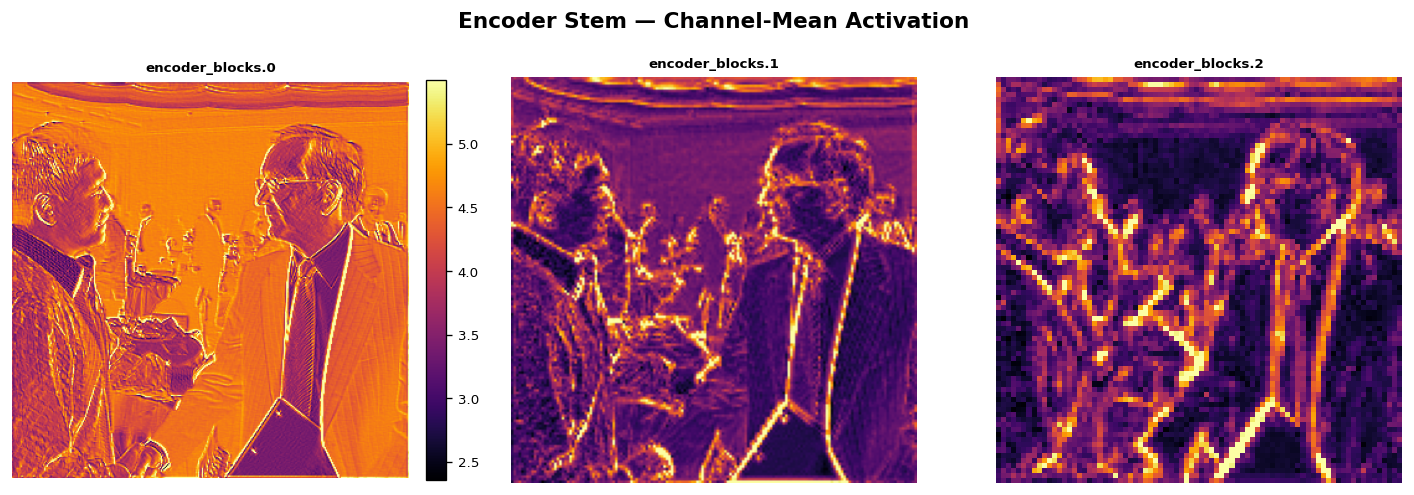

In [7]:
# ── Stem heatmaps: channel-mean ──
stem_keys = [
    "encoder_blocks.0",
    "encoder_blocks.1",
    "encoder_blocks.2",
]

plot_activation_summary(activations, stem_keys,
                        title="Encoder Stem — Channel-Mean Activation",
                        n_cols=3, figsize_per_row=4.0)
plt.show()


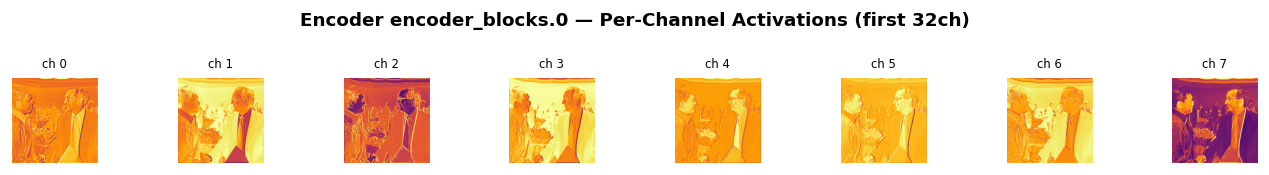

In [8]:
# ── Stem: Per-channel grids ──
stem_key = "encoder_blocks.0" if "encoder_blocks.0" in activations else list(activations.keys())[0]
fig = channel_heatmap_grid(
    activations[stem_key],
    n_cols=8,
    title=f"Encoder {stem_key} — Per-Channel Activations (first 32ch)",
    figsize_scale=1.4,
)
plt.show()


---
## 6B. Encoder Stage 1 — First Transformer Stage

**Stage 1**: Depthwise Conv3×3 s2 (128ch, 40→20) + 1× `UMobileViTEncoderLayer`  
Each encoder layer decomposes into: **local** → **global** (self-attention) → **expansion** (inverted bottleneck) → **out_norm** (residual).  
Resolution: 20×20, Channels: 128

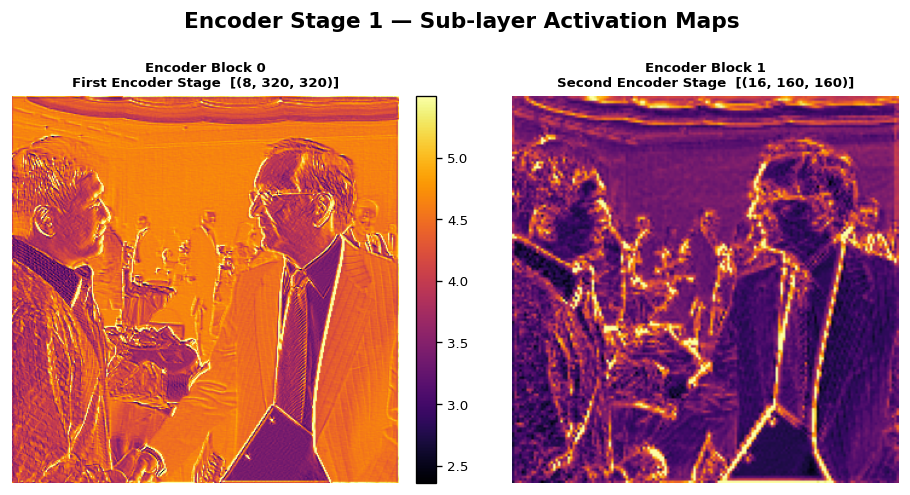

In [9]:
# ── Encoder Stage 1: Sub-layer breakdown ──
enc1_sub_keys = [
    ("encoder_blocks.0", "Encoder Block 0", "First Encoder Stage"),
    ("encoder_blocks.1", "Encoder Block 1", "Second Encoder Stage"),
]

plot_side_by_side_heatmaps(
    activations, enc1_sub_keys,
    suptitle="Encoder Stage 1 — Sub-layer Activation Maps",
    n_cols=2, figsize_per_cell=4.0,
)
plt.show()


---
## 6C. Encoder Stage 2 — Deeper Features

**Stage 2**: DW Conv3×3 s2 (20→10) + 2× `UMobileViTEncoderLayer`  
Resolution: 10×10, Channels: 128

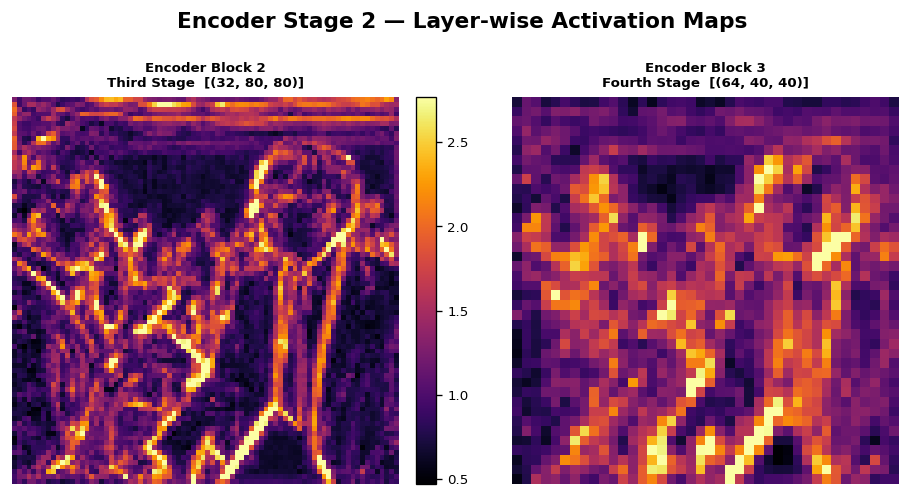

In [10]:
# ── Encoder Stage 2: Output of each layer ──
enc2_keys = [
    ("encoder_blocks.2", "Encoder Block 2", "Third Stage"),
    ("encoder_blocks.3", "Encoder Block 3", "Fourth Stage"),
]

plot_side_by_side_heatmaps(
    activations, enc2_keys,
    suptitle="Encoder Stage 2 — Layer-wise Activation Maps",
    n_cols=2, figsize_per_cell=4.0,
)
plt.show()


---
## 6D. Encoder Stage 3 — Bottleneck (no unfolding)

**Stage 3**: DW Conv3×3 s2 (10→5) + 2× `UMobileViTEncoderLayer` with `patch_size=(1,1)`  
At 5×5 resolution with patch_size=1, the transformer operates directly on each spatial  
position without unfolding — acting as a global context aggregator.  
Resolution: 5×5, Channels: 128

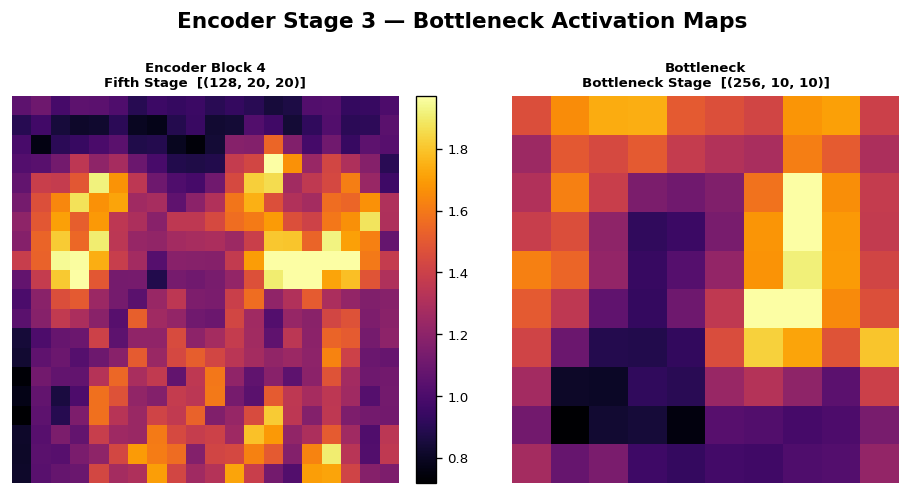

In [11]:
# ── Encoder Stage 3: Bottleneck features ──
enc3_keys = [
    ("encoder_blocks.4", "Encoder Block 4", "Fifth Stage") if "encoder_blocks.4" in activations else ("encoder_blocks.3", "Encoder Block 3", "Fourth Stage"),
    ("bottleneck", "Bottleneck", "Bottleneck Stage") if "bottleneck" in activations else ("bottleneck_out", "Bottleneck Out", "Bottleneck Stage"),
]

plot_side_by_side_heatmaps(
    activations, enc3_keys,
    suptitle="Encoder Stage 3 — Bottleneck Activation Maps",
    n_cols=2, figsize_per_cell=4.0,
)
plt.show()


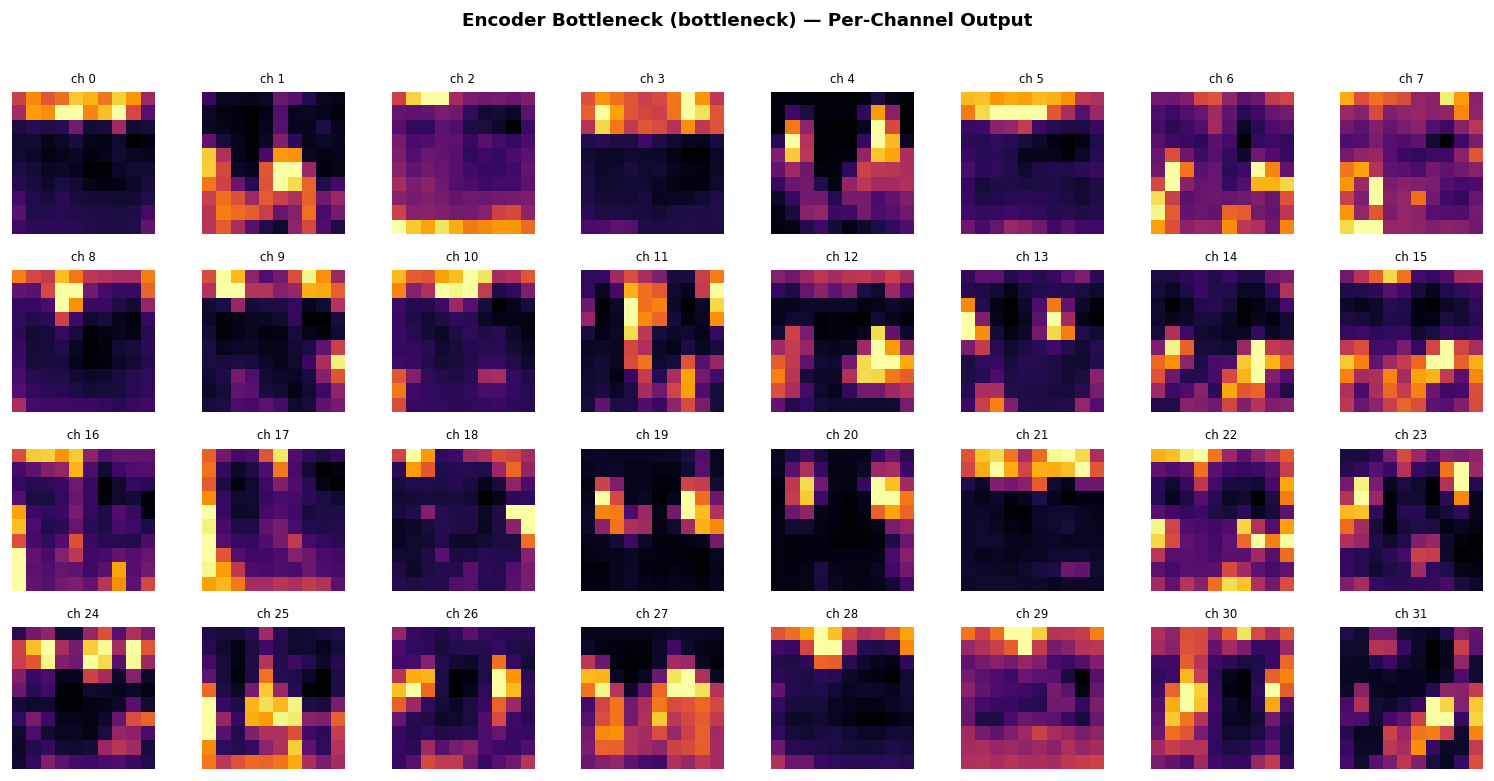

In [12]:
# ── Encoder Stage 3: Per-channel grid ──
btn_key = "bottleneck" if "bottleneck" in activations else ("bottleneck_out" if "bottleneck_out" in activations else list(activations.keys())[-2])
fig = channel_heatmap_grid(
    activations[btn_key],
    n_cols=8,
    title=f"Encoder Bottleneck ({btn_key}) — Per-Channel Output",
    figsize_scale=1.6,
)
plt.show()


---
## 6E. Encoder — Cross-Stage Comparison

How do features evolve across encoder stages? Compare the output of each stage.

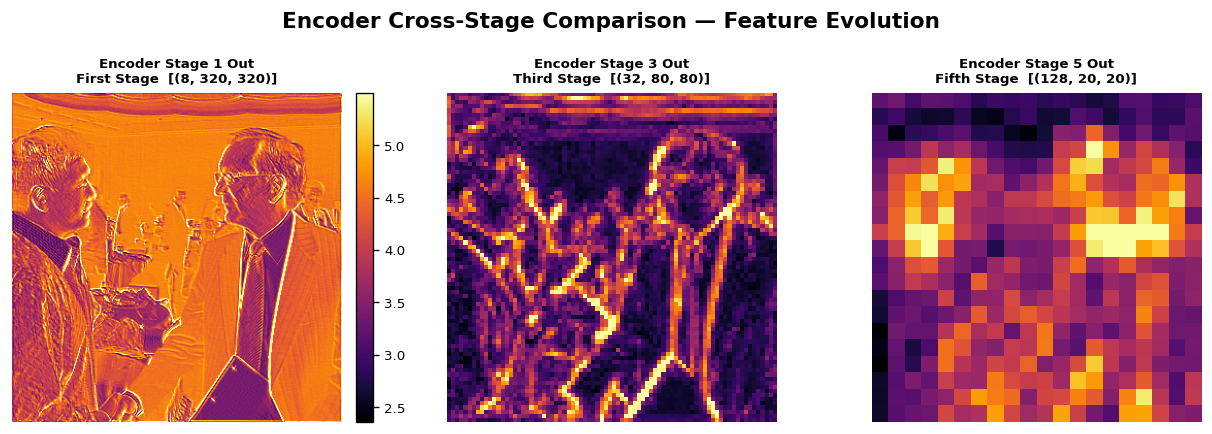

In [13]:
# Cross-stage comparison: final output of each encoder stage
cross_stage_keys = [
    ("encoder_blocks.0", "Encoder Stage 1 Out", "First Stage"),
    ("encoder_blocks.2", "Encoder Stage 3 Out", "Third Stage"),
    ("encoder_blocks.4", "Encoder Stage 5 Out", "Fifth Stage") if "encoder_blocks.4" in activations else ("encoder_blocks.3", "Encoder Stage 4 Out", "Fourth Stage"),
]

plot_side_by_side_heatmaps(
    activations, cross_stage_keys,
    suptitle="Encoder Cross-Stage Comparison — Feature Evolution",
    n_cols=3, figsize_per_cell=3.5,
)
plt.show()


---
## 7A. Decoder Stage 1 — First Upsampling + Cross-Attention

**Stage 1**: Upsample ×2 (5→10) + 2× `UMobileViTDecoderLayer` (cross-attention with encoder Stage 2 skip)  
Resolution: 10×10, Channels: 128

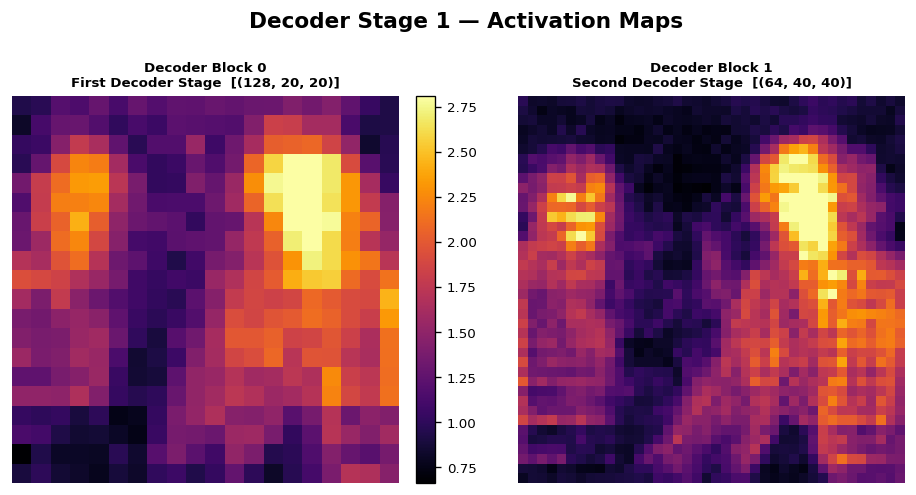

In [14]:
# ── Decoder Stage 1 ──
dec1_keys = [
    ("decoder_blocks.0", "Decoder Block 0", "First Decoder Stage"),
    ("decoder_blocks.1", "Decoder Block 1", "Second Decoder Stage"),
]

plot_side_by_side_heatmaps(
    activations, dec1_keys,
    suptitle="Decoder Stage 1 — Activation Maps",
    n_cols=2, figsize_per_cell=4.0,
)
plt.show()


---
## 7B. Decoder Stage 2 — Continued Upsampling

**Stage 2**: Upsample ×2 (10→20) + 1× `UMobileViTDecoderLayer` (cross-attention with encoder Stage 1 skip)  
Resolution: 20×20, Channels: 128

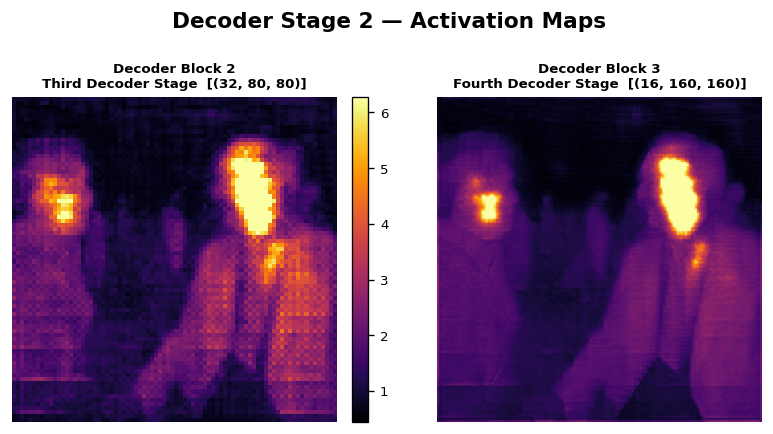

In [15]:
# ── Decoder Stage 2 ──
dec2_keys = [
    ("decoder_blocks.2", "Decoder Block 2", "Third Decoder Stage"),
    ("decoder_blocks.3", "Decoder Block 3", "Fourth Decoder Stage"),
]

plot_side_by_side_heatmaps(
    activations, dec2_keys,
    suptitle="Decoder Stage 2 — Activation Maps",
    n_cols=2, figsize_per_cell=3.5,
)
plt.show()


---
## 7C. Decoder Out Block — Additive Memory Fusion

**Out Block**: Upsample ×2 (20→40) + 1× `UMobileViTDecoderConcatLayer`  
The ConcatLayer uses **additive memory projection** (no transformer) to fuse encoder stem[2] features.  
Resolution: 40×40, Channels: 128

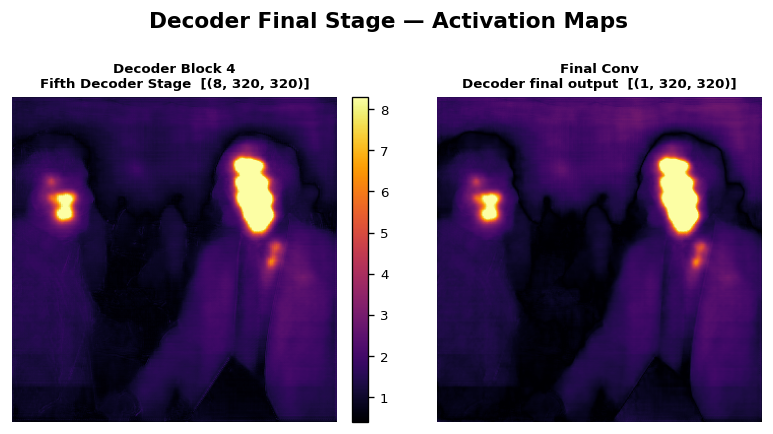

In [16]:
# ── Decoder Out Block ──
dec_out_keys = [
    ("decoder_blocks.4", "Decoder Block 4", "Fifth Decoder Stage") if "decoder_blocks.4" in activations else ("decoder_blocks.3", "Decoder Block 3", "Fourth Stage"),
    ("final_conv", "Final Conv", "Decoder final output"),
]

plot_side_by_side_heatmaps(
    activations, dec_out_keys,
    suptitle="Decoder Final Stage — Activation Maps",
    n_cols=2, figsize_per_cell=3.5,
)
plt.show()


---
## 7D. Decoder — Cross-Stage Comparison

How do features evolve through the decoder?

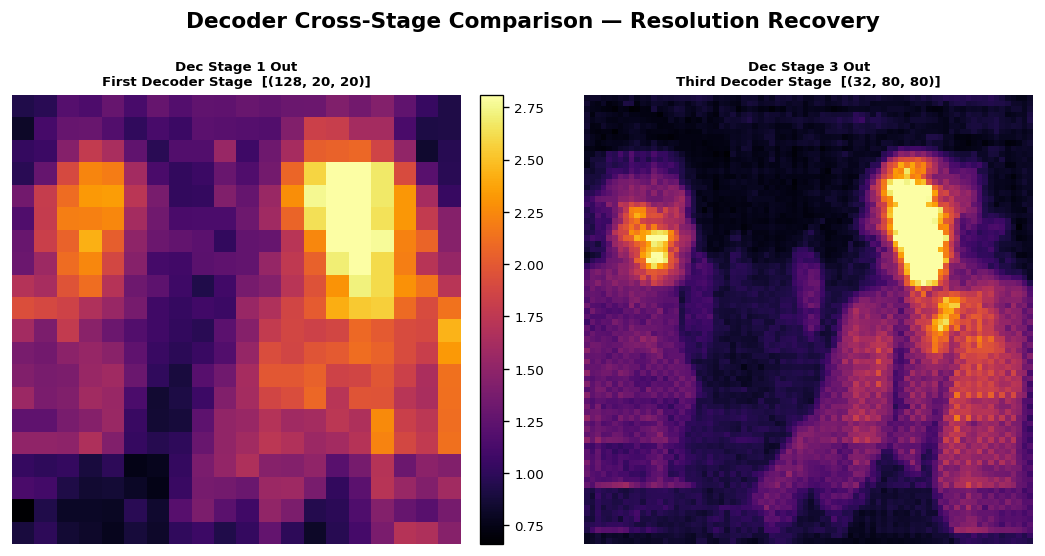

In [17]:
# Cross-stage decoder comparison
dec_cross_keys = [
    ("decoder_blocks.0", "Dec Stage 1 Out", "First Decoder Stage"),
    ("decoder_blocks.2", "Dec Stage 3 Out", "Third Decoder Stage"),
]

plot_side_by_side_heatmaps(
    activations, dec_cross_keys,
    suptitle="Decoder Cross-Stage Comparison — Resolution Recovery",
    n_cols=2, figsize_per_cell=4.5,
)
plt.show()


---
## 8A. Segmentation Head — Upsample Pathway

The `UpsampleHead` progressively restores spatial resolution with skip connections  
from encoder stem outputs:
- **x2**: 128→64ch, 40→80 (concat with stem[1] 64ch)
- **x4**:  64→32ch, 80→160 (concat with stem[0] 32ch)
- **x8**:  32→16ch, 160→320 (final)

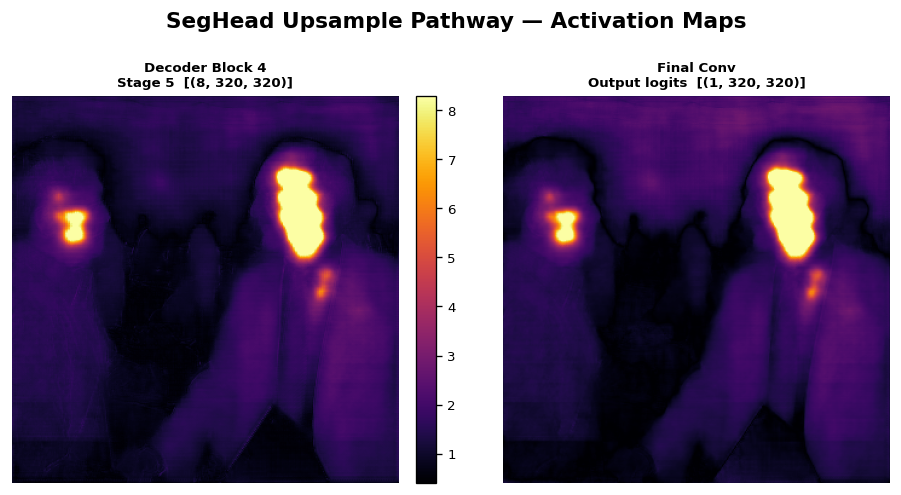

In [18]:
# ── SegHead Upsample stages ──
seghead_keys = [
    ("decoder_blocks.4", "Decoder Block 4", "Stage 5") if "decoder_blocks.4" in activations else ("decoder_blocks.3", "Decoder Block 3", "Stage 4"),
    ("final_conv", "Final Conv", "Output logits"),
]

plot_side_by_side_heatmaps(
    activations, seghead_keys,
    suptitle="SegHead Upsample Pathway — Activation Maps",
    n_cols=2, figsize_per_cell=4.0,
)
plt.show()


---
## 8B. Feature Refinement & Final Classifier

**Refinement Block**: Dilated Conv (d=2) + Spatial Attention (avg/max pooling → Conv7×7 → Sigmoid)  
**Classifier**: Depthwise 3×3 → ReLU → Pointwise 1×1 → logits (8 classes)

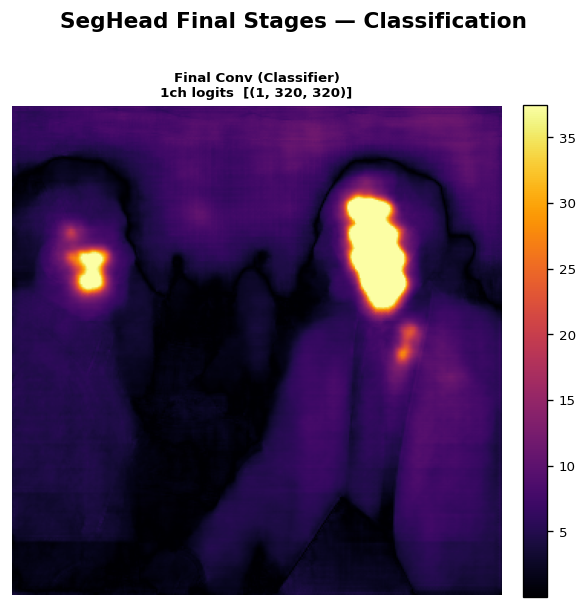

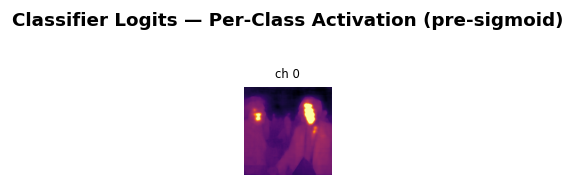

In [19]:
# ── Refinement + Classifier ──
head_final_keys = [
    ("final_conv", "Final Conv (Classifier)", "1ch logits"),
]

plot_side_by_side_heatmaps(
    activations, head_final_keys,
    suptitle="SegHead Final Stages — Classification",
    n_cols=1, figsize_per_cell=5.0,
)
plt.show()

# Also show per-channel classifier logits
if "final_conv" in activations:
    fig = channel_heatmap_grid(
        activations["final_conv"],
        n_cols=1,
        title="Classifier Logits — Per-Class Activation (pre-sigmoid)",
        figsize_scale=1.5,
    )
    plt.show()


---
## 9. End-to-End Feature Evolution — Comprehensive View

A single figure showing the channel-mean activation at every major pipeline stage,  
from input to output. This gives a complete picture of how the representation evolves.

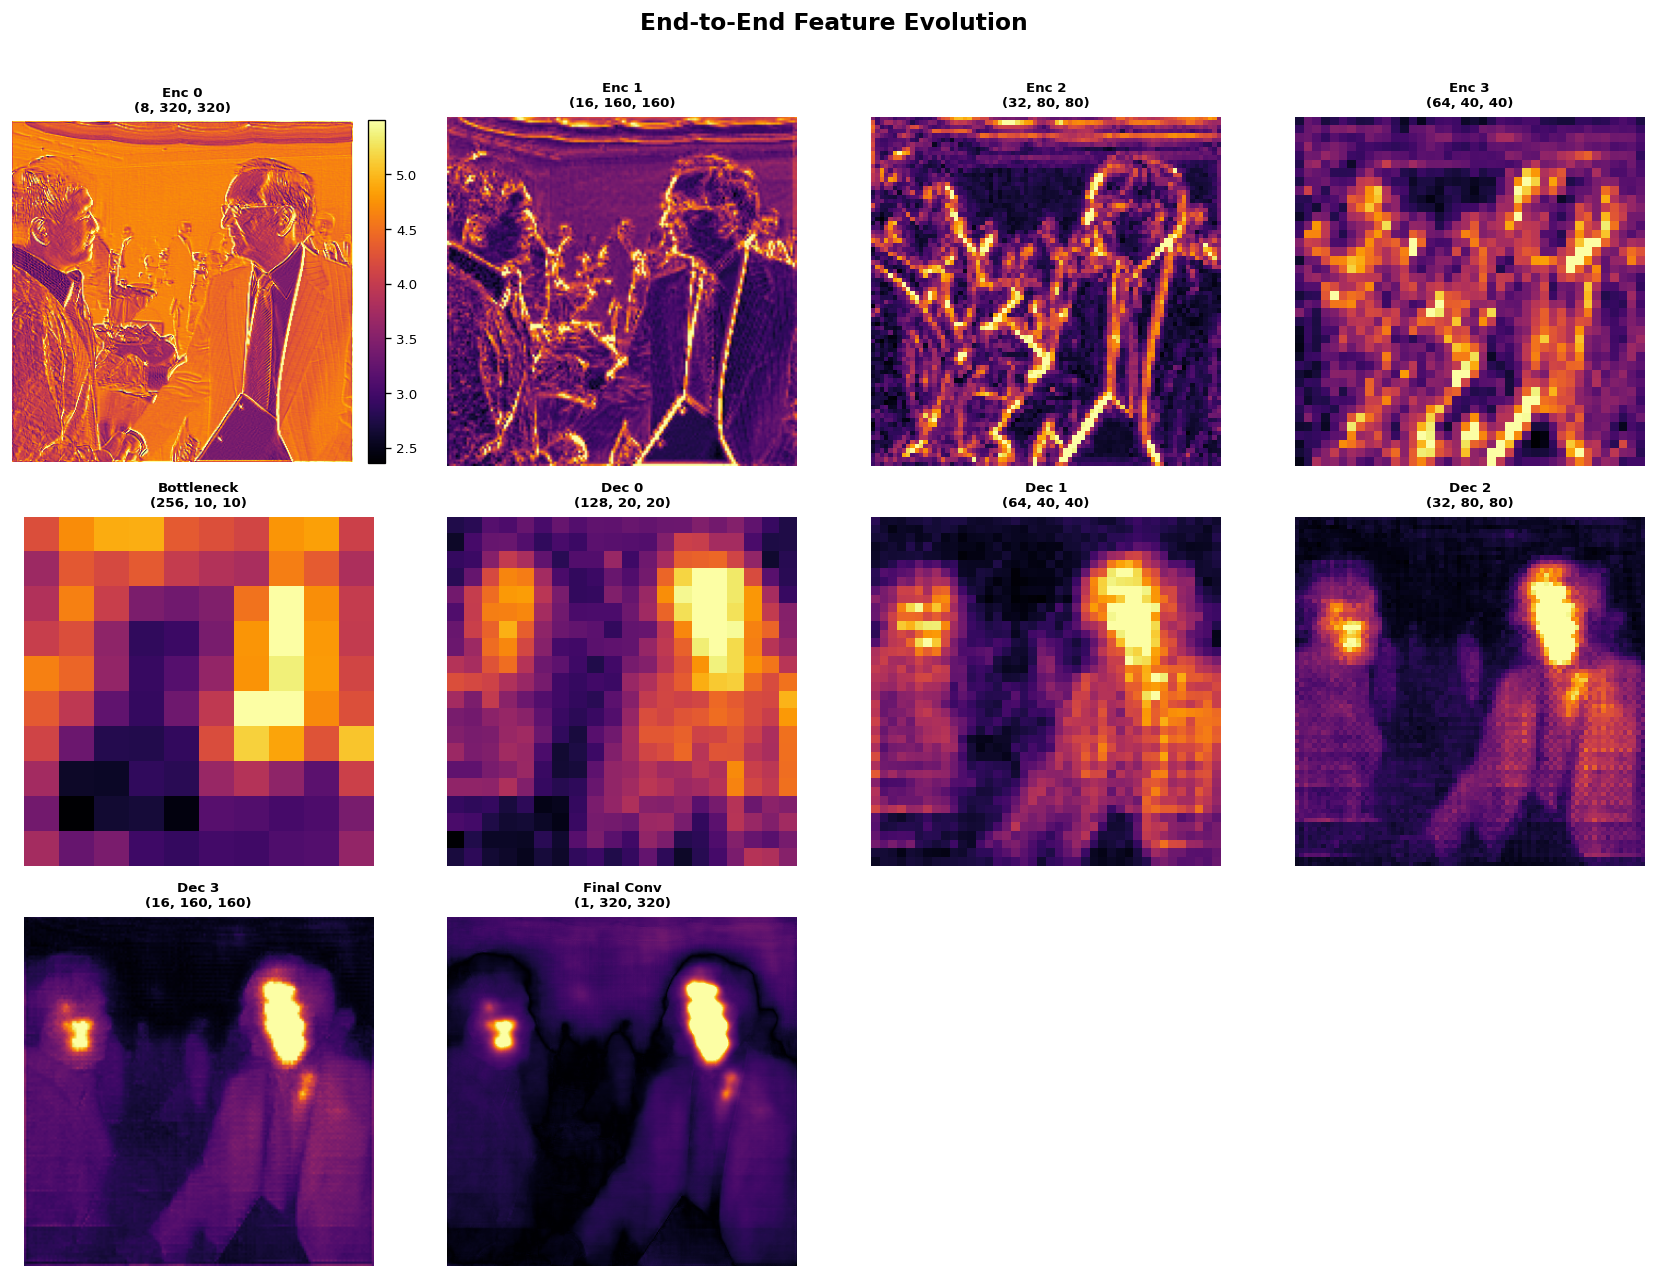

In [20]:
# ── Full pipeline overview ──
pipeline_keys = [
    "encoder_blocks.0",
    "encoder_blocks.1",
    "encoder_blocks.2",
    "encoder_blocks.3",
    "bottleneck" if "bottleneck" in activations else "bottleneck_out",
    "decoder_blocks.0",
    "decoder_blocks.1",
    "decoder_blocks.2",
    "decoder_blocks.3",
    "final_conv",
]
pipeline_labels = [
    "Enc 0", "Enc 1", "Enc 2", "Enc 3", "Bottleneck",
    "Dec 0", "Dec 1", "Dec 2", "Dec 3", "Final Conv"
]

valid_keys = [k for k in pipeline_keys if k in activations]
valid_labels = [lbl for k, lbl in zip(pipeline_keys, pipeline_labels) if k in activations]

n_cols = 4
n_rows = int(np.ceil(len(valid_keys) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
axes = axes.flatten()

for i, (key, label) in enumerate(zip(valid_keys, valid_labels)):
    tensor = activations[key]
    shape_str = f"{tuple(tensor.shape[1:])}"
    activation_heatmap(tensor, axes[i], title=f"{label}\n{shape_str}", show_colorbar=(i == 0))

for j in range(len(valid_keys), len(axes)):
    axes[j].axis("off")

fig.suptitle("End-to-End Feature Evolution", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()

# Save for paper
os.makedirs("paper_figures", exist_ok=True)
plt.savefig("paper_figures/05_feature_evolution.pdf")
plt.show()


---
## 10. Prediction vs Ground Truth

Verify the model is producing sensible predictions on this sample.

Saved predicted mask to: /home/lenovo/a3_dl_fn/UNet_Training_From_Scratch/000000008532_mask.png
Saved predicted mask to: /home/lenovo/a3_dl_fn/UNet_Training_From_Scratch/000000002685_mask.png


Saved predicted mask to: /home/lenovo/a3_dl_fn/UNet_Training_From_Scratch/000000004134_mask.png
Saved predicted mask to: /home/lenovo/a3_dl_fn/UNet_Training_From_Scratch/000000005529_mask.png


Saved dashboard to: paper_figures/05_prediction_vs_gt.pdf


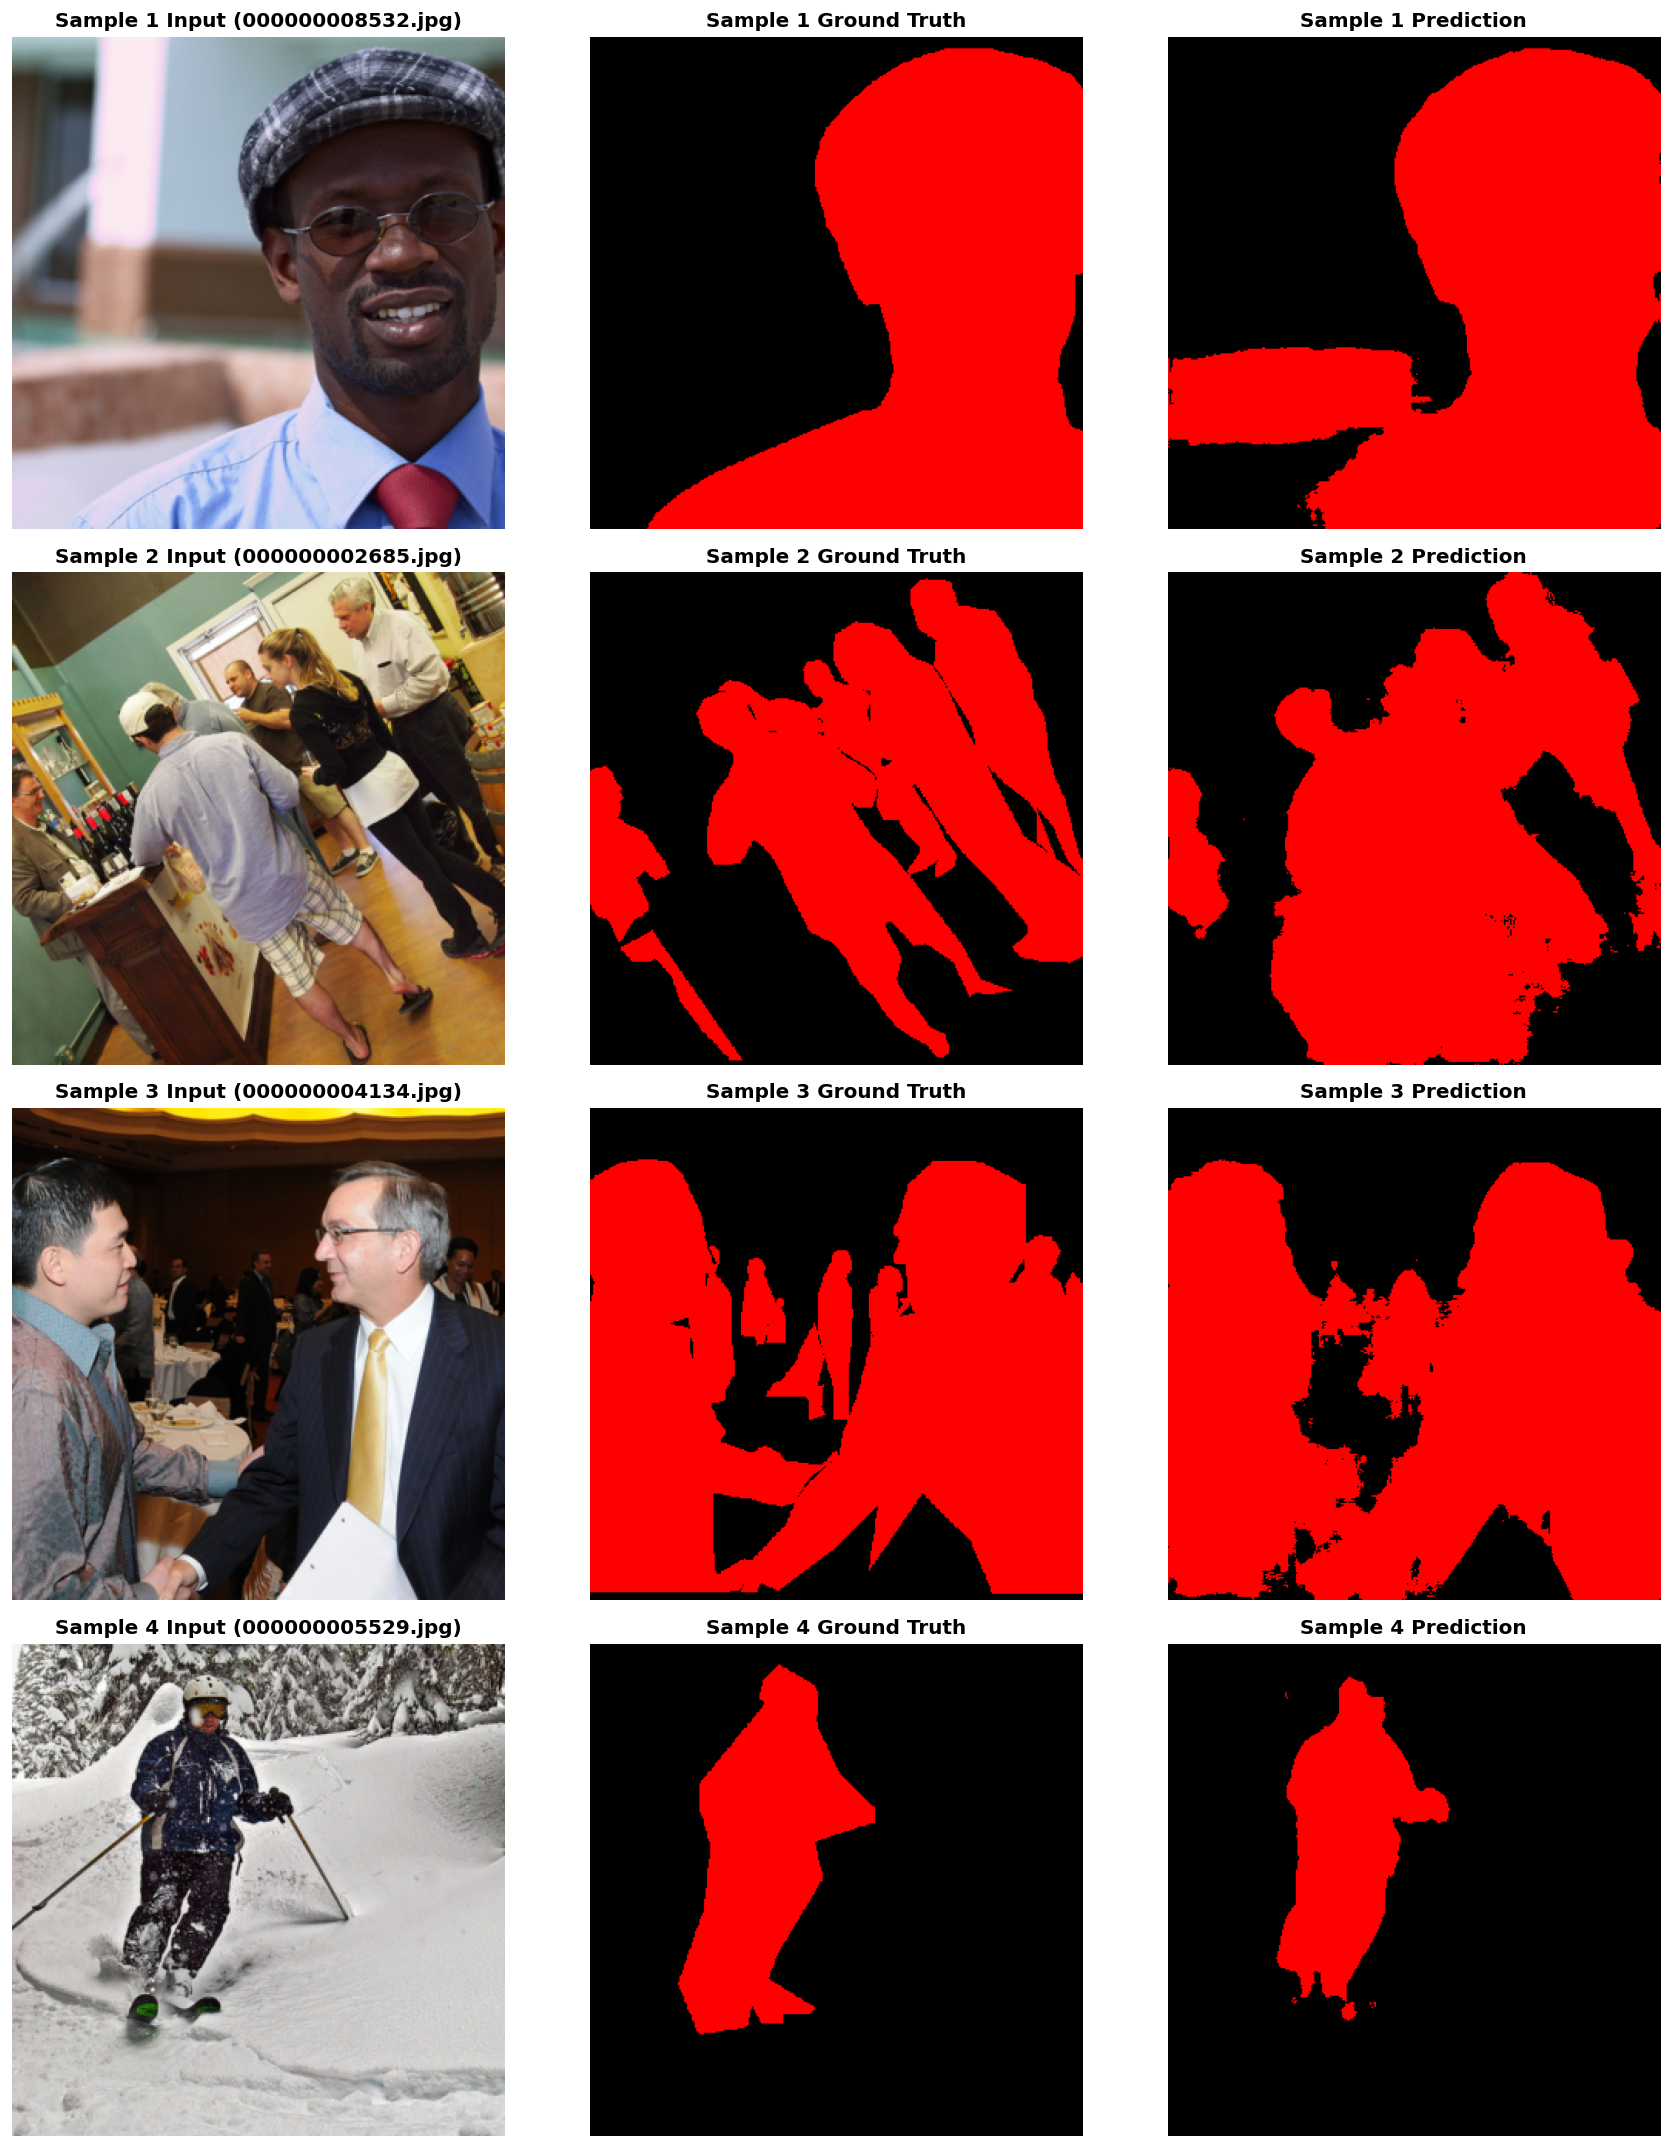

In [21]:
# --- Section 10: Prediction vs Ground Truth -------------------------------------

# ── Prediction vs GT for all 4 custom images ──
fig, axes = plt.subplots(4, 3, figsize=(15, 18))
img_names = ["000000008532", "000000002685", "000000004134", "000000005529"]

for idx in range(4):
    val_idx = custom_target_indices[idx]
    
    # Check if we should use local fallback
    use_local_fallback = False
    if val_idx >= len(custom_val_loader.dataset):
        use_local_fallback = True
    else:
        try:
            img_tensor, mask_tensor = custom_val_loader.dataset[val_idx]
        except Exception as e:
            use_local_fallback = True
            
    if use_local_fallback:
        from PIL import Image as PILImage
        import torchvision.transforms.functional as TF
        from src.dataset import IMAGENET_MEAN, IMAGENET_STD
        from torchvision.transforms import InterpolationMode
        
        local_img_path = f"/home/lenovo/a3_dl_fn/UNet_Training_From_Scratch/{img_names[idx]}.jpg"
        image = PILImage.open(local_img_path).convert("RGB")
        short_edge = min(CFG["image_size"])
        img = TF.resize(image, short_edge, interpolation=InterpolationMode.BILINEAR)
        img_tensor = TF.center_crop(img, CFG["image_size"])
        img_tensor = TF.to_tensor(img_tensor)
        img_tensor = TF.normalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD)
        mask_tensor = torch.zeros(1, *CFG["image_size"])
        
    # Prepare inputs
    img_gpu_target = img_tensor.unsqueeze(0).to(device)
    
    # Run prediction
    with torch.no_grad():
        logits = model(img_gpu_target)
        if logits.shape[1] == 1:
            pred = (logits > 0).cpu().int()
        else:
            pred = logits.argmax(dim=1).cpu()
            
    img_np = denormalize(img_tensor)
    gt = mask_tensor.squeeze().numpy() if isinstance(mask_tensor, torch.Tensor) else mask_tensor
    pr = pred[0].squeeze().numpy()
    
    # Plot Input Image
    axes[idx, 0].imshow(img_np)
    axes[idx, 0].set_title(f"Sample {idx+1} Input ({img_names[idx]}.jpg)", fontweight="bold")
    axes[idx, 0].axis("off")
    
    # Plot Ground Truth
    axes[idx, 1].imshow(label_to_color(gt, info.palette))
    axes[idx, 1].set_title(f"Sample {idx+1} Ground Truth", fontweight="bold")
    axes[idx, 1].axis("off")
    
    # Plot Prediction
    colored_pred = label_to_color(pr, info.palette)
    axes[idx, 2].imshow(colored_pred)
    axes[idx, 2].set_title(f"Sample {idx+1} Prediction", fontweight="bold")
    axes[idx, 2].axis("off")
    
    # Save mask predictions for each image to file next to the original files
    mask_save_path = f"/home/lenovo/a3_dl_fn/UNet_Training_From_Scratch/{img_names[idx]}_mask.png"
    from PIL import Image as PILImage
    # Save the binary/colored prediction mask
    PILImage.fromarray(colored_pred).save(mask_save_path)
    print(f"Saved predicted mask to: {mask_save_path}")

# Legend
palette_01 = info.palette / 255.0
patches = [mpatches.Patch(color=palette_01[i], label=name)
           for i, name in enumerate(info.class_names)]
fig.legend(handles=patches, loc="lower center", ncol=4, frameon=False,
           bbox_to_anchor=(0.5, 0.05), fontsize=10)

plt.tight_layout()
os.makedirs("paper_figures", exist_ok=True)
fig.savefig("paper_figures/05_prediction_vs_gt.pdf", bbox_inches="tight", dpi=150)
print("Saved dashboard to: paper_figures/05_prediction_vs_gt.pdf")
plt.show()


---
## 11. Per-Stage Activation Statistics

Quantitative summary: mean, std, sparsity (fraction of near-zero activations)  
for each major stage. This reveals how activation patterns change through the network.

Layer                                                     Mean         Std    Sparsity                 Shape
--------------------------------------------------------------------------------------------------------------
  encoder_blocks.0                                      2.3333      4.1411      0.000      (1, 8, 320, 320)
  encoder_blocks.1                                     -0.2857      2.8570      0.000     (1, 16, 160, 160)
  encoder_blocks.2                                     -0.0015      1.5472      0.000       (1, 32, 80, 80)
  encoder_blocks.3                                     -0.0086      1.3936      0.000       (1, 64, 40, 40)
  encoder_blocks.4                                     -0.0151      1.3280      0.000      (1, 128, 20, 20)
  bottleneck                                            0.2550      0.4871      0.000      (1, 256, 10, 10)
  decoder_blocks.0                                      0.0005      1.2275      0.000      (1, 128, 20, 20)
  decoder_blocks.1      


Saved: paper_figures/05_activation_statistics.pdf


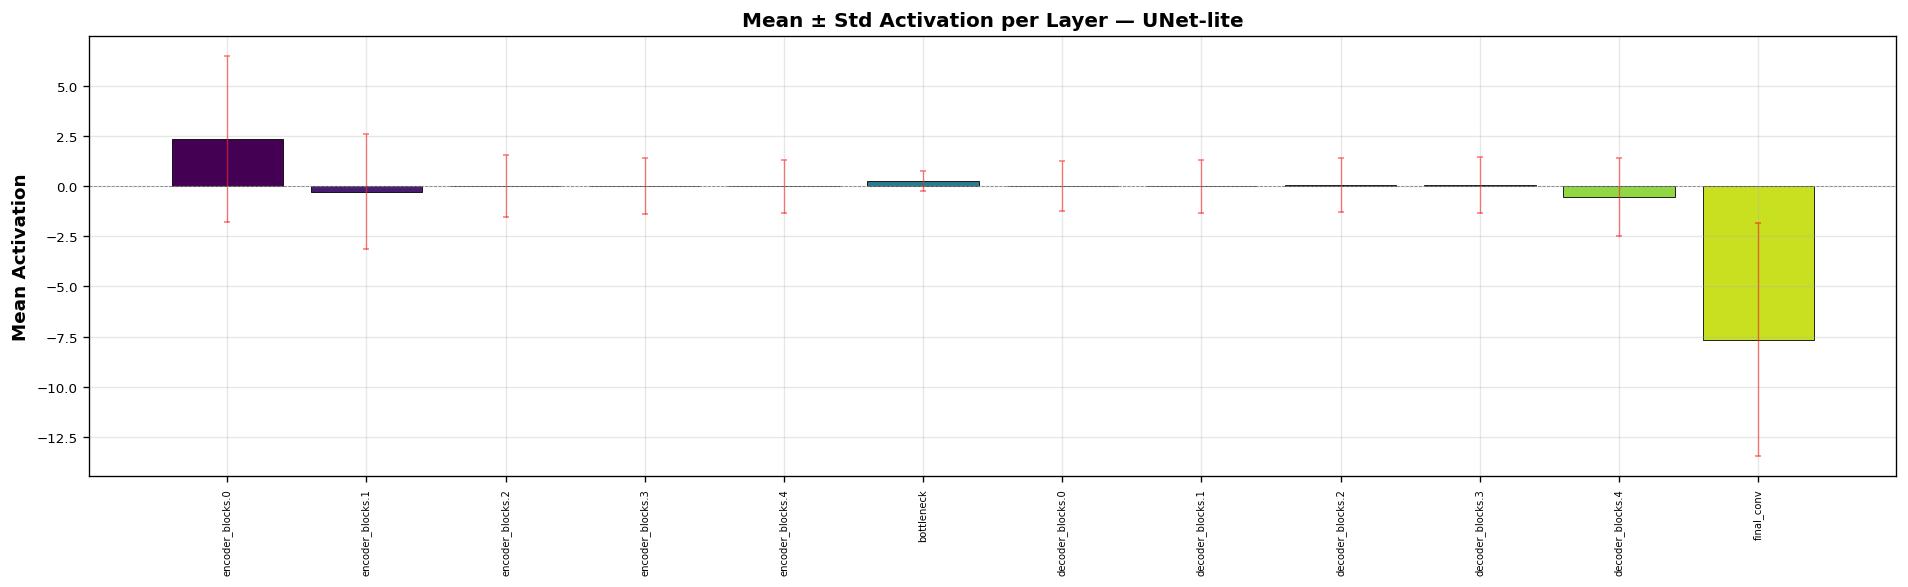

In [22]:
# ── Activation statistics ──
print(f"{'Layer':<50s}  {'Mean':>10s}  {'Std':>10s}  {'Sparsity':>10s}  {'Shape':>20s}")
print("-" * 110)

stats_data = []
for name, tensor in activations.items():
    t = tensor.float()
    mean_val = t.mean().item()
    std_val = t.std().item()
    # Sparsity: fraction of channels where absolute activation < 1% of max
    ch_max = t[0].abs().amax(dim=(1, 2))  # per-channel max
    sparsity = (ch_max < 0.01 * ch_max.max()).float().mean().item()
    shape_str = str(tuple(t.shape))
    print(f"  {name:<48s}  {mean_val:>10.4f}  {std_val:>10.4f}  {sparsity:>9.3f}  {shape_str:>20s}")
    stats_data.append((name, mean_val, std_val, sparsity, t.shape))

# Plot mean activation by stage
fig, ax = plt.subplots(figsize=(16, 5))
names_short = [s[0].replace("encoder.", "enc.").replace("decoder.", "dec.").replace("seg_head.", "seg.")[:45]
               for s in stats_data]
means = [s[1] for s in stats_data]
stds = [s[2] for s in stats_data]

x = np.arange(len(names_short))
bars = ax.bar(x, means, color=[plt.cm.viridis(i / len(x)) for i in range(len(x))], edgecolor="black", linewidth=0.5)
ax.errorbar(x, means, yerr=stds, fmt="none", ecolor="red", capsize=2, alpha=0.5, linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(names_short, rotation=90, fontsize=6)
ax.set_ylabel("Mean Activation", fontweight="bold")
ax.set_title("Mean ± Std Activation per Layer — UNet-lite", fontweight="bold")
ax.axhline(y=0, color="gray", linewidth=0.5, linestyle="--")
plt.tight_layout()

os.makedirs("paper_figures", exist_ok=True)
fig.savefig("paper_figures/05_activation_statistics.pdf", bbox_inches="tight", dpi=150)
print("\nSaved: paper_figures/05_activation_statistics.pdf")
plt.show()

---
## 12. Global Block Attention Map Analysis

For a selected transformer layer, visualise the attention patterns by comparing  
pre- and post-transformer feature maps. The difference highlights what spatial  
relationships the self/cross-attention is capturing.

Saved: paper_figures/05_attention_delta.pdf


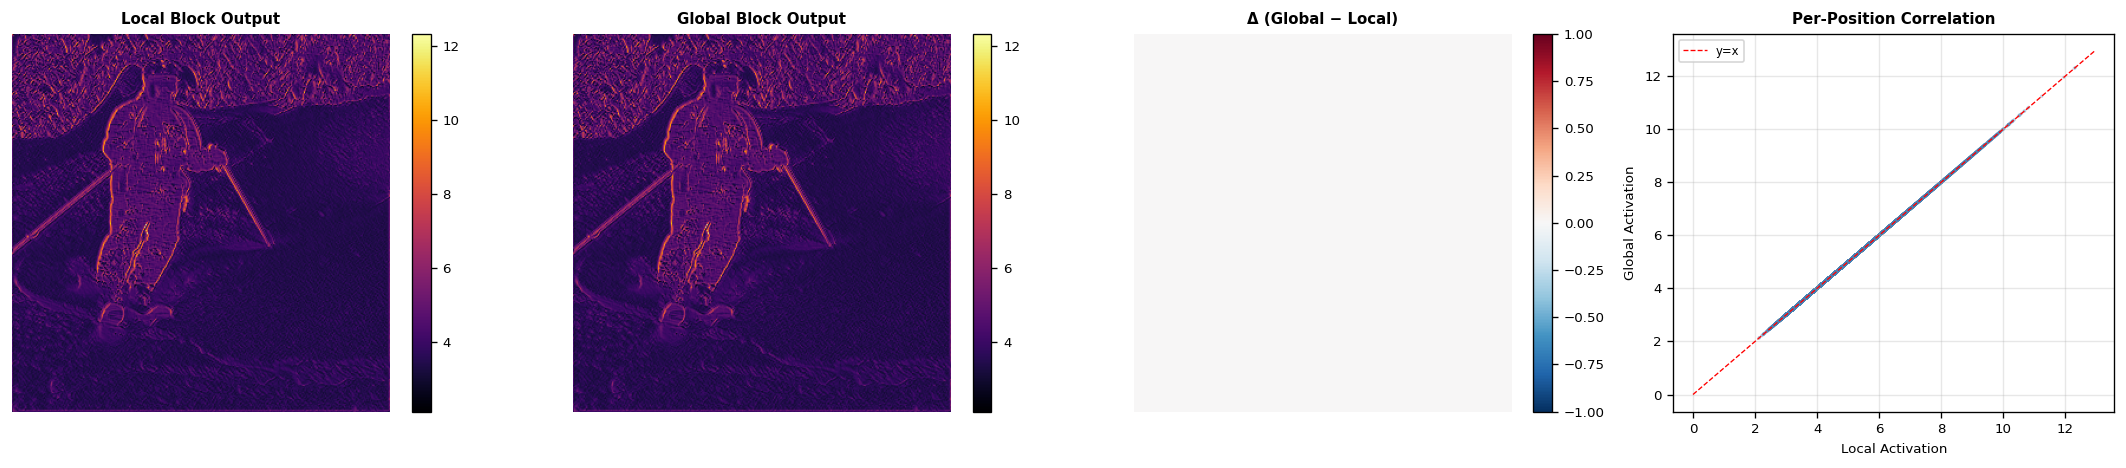

In [23]:
# --- Section 12: Global Block Attention Map Analysis ------------------------------

try:
    from cv_nets.utils.functional import fold_custom
except ImportError:
    def fold_custom(x, *args, **kwargs):
        return x

# Map to our actual keys if we want to compare, otherwise use old keys which will be skipped
attention_pairs = [
    ("encoder_blocks.0",  "encoder_blocks.0", None, "Enc Block 0 vs itself"),
]

fig, axes = plt.subplots(len(attention_pairs), 4, figsize=(18, 4 * len(attention_pairs)))
if len(attention_pairs) == 1:
    axes = axes.reshape(1, -1)

for row, (local_key, global_key, patch_size, title) in enumerate(attention_pairs):
    if local_key not in activations or global_key not in activations:
        for ax in axes[row]:
            ax.axis("off")
        continue

    local_feat = activations[local_key][0].abs().mean(dim=0)  # (H, W)
    global_tensor = activations[global_key]
    global_feat = global_tensor[0].abs().mean(dim=0)  # (H, W)
    delta = global_feat - local_feat

    # Local
    im0 = axes[row, 0].imshow(local_feat.numpy(), cmap="inferno")
    axes[row, 0].set_title("Local Block Output", fontsize=9, fontweight="bold")
    axes[row, 0].axis("off")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    # Global
    im1 = axes[row, 1].imshow(global_feat.numpy(), cmap="inferno")
    axes[row, 1].set_title("Global Block Output", fontsize=9, fontweight="bold")
    axes[row, 1].axis("off")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    # Delta
    vmax = max(abs(delta.min().item()), abs(delta.max().item()))
    if vmax == 0: vmax = 1.0
    im2 = axes[row, 2].imshow(delta.numpy(), cmap="RdBu_r",
                               norm=Normalize(vmin=-vmax, vmax=vmax))
    axes[row, 2].set_title("Δ (Global − Local)", fontsize=9, fontweight="bold")
    axes[row, 2].axis("off")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046)

    # Scatter
    axes[row, 3].scatter(local_feat.flatten().numpy(), global_feat.flatten().numpy(),
                          alpha=0.3, s=4, c="steelblue", edgecolors="none")
    lims = [0, max(local_feat.max().item(), global_feat.max().item()) * 1.05]
    axes[row, 3].plot(lims, lims, "r--", linewidth=0.8, label="y=x")
    axes[row, 3].set_xlabel("Local Activation", fontsize=8)
    axes[row, 3].set_ylabel("Global Activation", fontsize=8)
    axes[row, 3].set_title("Per-Position Correlation", fontsize=9, fontweight="bold")
    axes[row, 3].legend(fontsize=7)

    axes[row, 0].set_ylabel(title, fontsize=10, fontweight="bold", rotation=90,
                             labelpad=20, va="center")

plt.tight_layout()
os.makedirs("paper_figures", exist_ok=True)
fig.savefig("paper_figures/05_attention_delta.pdf", bbox_inches="tight", dpi=150)
print("Saved: paper_figures/05_attention_delta.pdf")
plt.show()


---
## 13. Summary

Key observations from the model dissection:

In [24]:
print("=" * 72)
print("  MODEL DISSECTION SUMMARY")
print("=" * 72)
print(f"  Dataset:            {info.name}")
print(f"  Model variant:      {CFG['variant'].upper()}")
print(f"  Active layers:      {', '.join(list(activations.keys()))}")
print("=" * 72)


  MODEL DISSECTION SUMMARY
  Dataset:            COCO Person
  Model variant:      UNET_LITE_NO_ATTN
  Active layers:      encoder_blocks.0, encoder_blocks.1, encoder_blocks.2, encoder_blocks.3, encoder_blocks.4, bottleneck, decoder_blocks.0, decoder_blocks.1, decoder_blocks.2, decoder_blocks.3, decoder_blocks.4, final_conv
